# 01b. Data Exploration — Full Dataset (Excel)

Explores the full Apify-scraped Excel file, which contains 82 columns
including review dates, platform, reviewer experience, and owner responses
that were absent from the original cleaned CSV.

**Input:** `../Data/Raw/ushmm_tripadvisor_full.xlsx`  
**Output:** `../Data/Processed/ushmm_tripadvisor_full_clean.csv`

## New variables available
- `published_date` — date review was written (100% complete)
- `travel_date` — month of visit (96.3% complete)
- `platform` — device used (OTHER/MOBILE/TABLET)
- `reviewer_total_contributions` — reviewer's TripAdvisor experience
- `reviewer_helpful_votes` — reviewer's credibility signal
- `has_owner_response` — whether USHMM responded
- `review_title` — headline of the review
- `lang` — detected language of review

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from collections import Counter

mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["DejaVu Sans"],
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

In [4]:
# Load full Excel file
raw = pd.read_excel("../Data/Raw/ushmm_tripadvisor_full.xlsx")
print(f"Raw shape: {raw.shape}")
print(f"Columns: {len(raw.columns)}")

Raw shape: (11367, 82)
Columns: 82


## 1. Extract and Rename Relevant Columns

In [5]:
df = pd.DataFrame({
    "review_id":                    raw["id"],
    "rating":                       raw["rating"],
    "review_title":                 raw["title"],
    "review_text":                  raw["text"],
    "group_type":                   raw["tripType"],
    "reviewer_location":            raw["user/userLocation/name"],
    "likes":                        raw["helpfulVotes"],
    "published_date":               pd.to_datetime(raw["publishedDate"]),
    "travel_date":                  raw["travelDate"],
    "platform":                     raw["publishedPlatform"],
    "lang":                         raw["lang"],
    "reviewer_total_contributions": raw["user/contributions/totalContributions"],
    "reviewer_helpful_votes":       raw["user/contributions/helpfulVotes"],
    "has_owner_response":           raw["ownerResponse/text"].notna(),
    "owner_response_text":          raw["ownerResponse/text"],
})

df["year"]  = df["published_date"].dt.year
df["month"] = df["published_date"].dt.to_period("M")

print(f"Working dataset: {df.shape}")
df.head()

Working dataset: (11367, 17)


,review_id,rating,review_title,review_text,group_type,reviewer_location,likes,published_date,travel_date,platform,lang,reviewer_total_contributions,reviewer_helpful_votes,has_owner_response,owner_response_text,year,month
0,969470511,5,"Very heartfelt, passionate, informitive",We spent four hours and could have spent eight...,COUPLES,"Bradley, Illinois",0,2024-09-12,2024-09,OTHER,en,479.0,135.0,False,NaN,2024,2024-09
1,966324889,5,When an old man explained the Warsaw milk cans...,We are Germans visiting this museum. Most of t...,FAMILY,"Heidelberg, Germany",1,2024-08-23,2024-08,OTHER,en,253.0,33.0,False,NaN,2024,2024-08
2,965353037,5,This place is incredible,This museum is incredible and incredibly impor...,FAMILY,"Otsego, Minnesota",0,2024-08-17,2024-08,MOBILE,en,1337.0,165.0,True,Thank you for visiting our museum.,2024,2024-08
3,965335373,5,Very worthwhile museum,I visited the Holocaust Museum in August 2024....,SOLO,"New York City, New York",0,2024-08-17,2024-08,MOBILE,en,3304.0,968.0,True,Thank you for sharing your experience with us.,2024,2024-08
4,965102947,4,Sad but lots of information,I learned so much. The place has a very sad vi...,FRIENDS,"Lewiston, New York",0,2024-08-16,2024-08,MOBILE,en,128.0,24.0,True,Thank you for sharing your experience with us.,2024,2024-08


In [6]:
# Completeness check
print("Non-null counts:")
print(df.count())
print(f"\nDate range: {df['published_date'].min().date()} to {df['published_date'].max().date()}")
print(f"Years covered: {df['year'].nunique()} ({df['year'].min()}–{df['year'].max()})")

Non-null counts:
review_id                       11367
rating                          11367
review_title                    11367
review_text                     11367
group_type                      10949
reviewer_location                8791
likes                           11367
published_date                  11367
travel_date                     10949
platform                        11367
lang                            11367
reviewer_total_contributions    11365
reviewer_helpful_votes          11365
has_owner_response              11367
owner_response_text               118
year                            11367
month                           11367
dtype: int64

Date range: 2002-11-30 to 2024-09-12
Years covered: 23 (2002–2024)


## 2. Language Distribution

In [7]:
lang_counts = df["lang"].value_counts()
print("Language distribution (top 15):")
print(lang_counts.head(15))
print(f"\nEnglish reviews: {(df['lang']=='en').sum()} ({(df['lang']=='en').mean()*100:.1f}%)")
print(f"Non-English reviews: {(df['lang']!='en').sum()} ({(df['lang']!='en').mean()*100:.1f}%)")

Language distribution (top 15):
lang
en    10114
pt      441
es      383
fr      103
it       91
ja       60
nl       42
de       42
ru       30
ko       12
da       10
sv        7
iw        6
pl        6
no        5
Name: count, dtype: int64

English reviews: 10114 (89.0%)
Non-English reviews: 1253 (11.0%)


## 3. Temporal Analysis

In [8]:
# Annual review counts
annual = df.groupby("year").size().rename("reviews")
print("Annual review counts:")
print(annual.to_string())

Annual review counts:
year
2002       1
2003       1
2004       2
2005       8
2006       2
2007      17
2008      19
2009      24
2010      35
2011     174
2012     984
2013     985
2014    1213
2015    2006
2016    1995
2017    1632
2018    1191
2019     759
2020      83
2021      36
2022      73
2023      90
2024      37


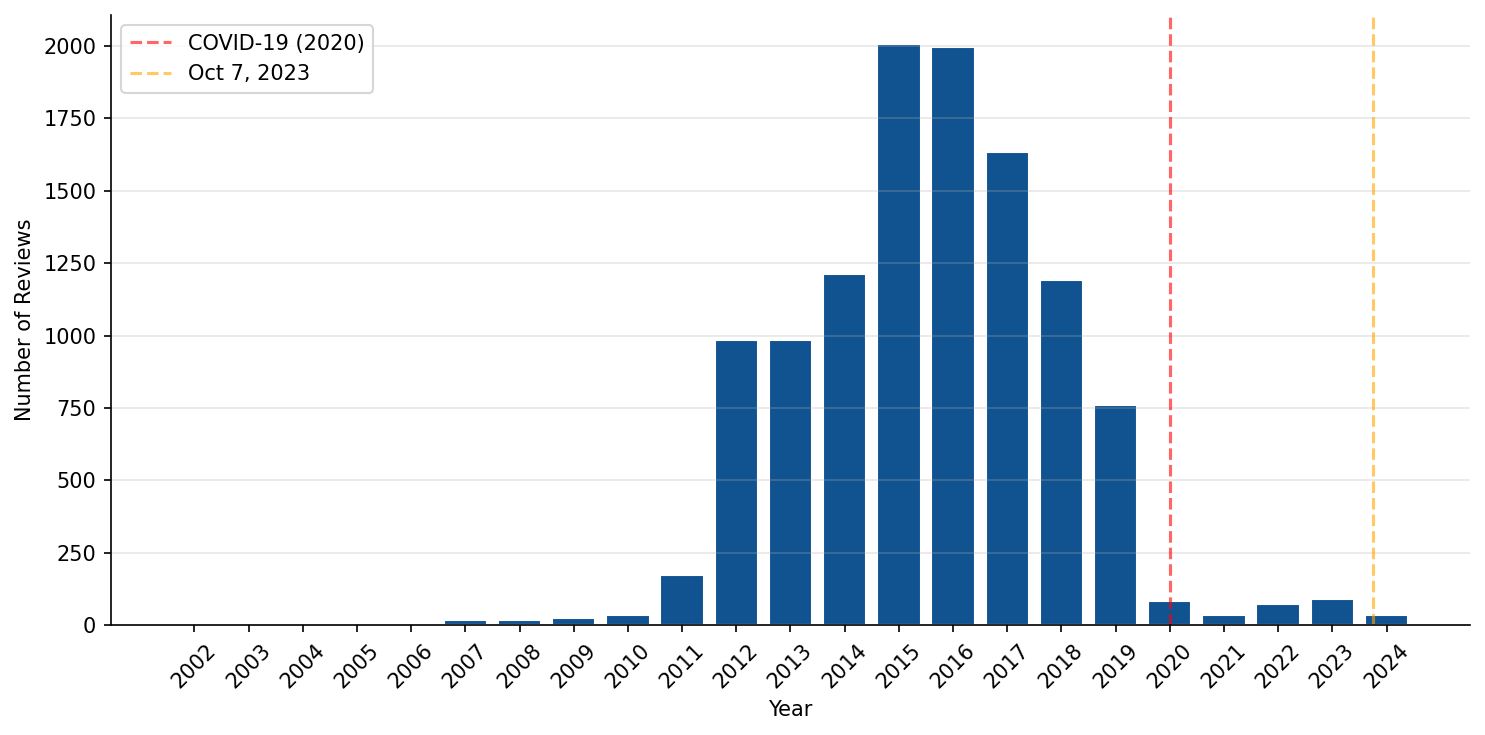

In [9]:
# Annual trend plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(annual.index, annual.values, color="#115391", edgecolor="white")

# Annotate key events
ax.axvline(2020, color="red", linestyle="--", alpha=0.6, label="COVID-19 (2020)")
ax.axvline(2023.75, color="orange", linestyle="--", alpha=0.6, label="Oct 7, 2023")

ax.set_xlabel("Year")
ax.set_ylabel("Number of Reviews")
ax.legend()
ax.grid(axis="y", alpha=0.3)
ax.set_xticks(annual.index)
ax.set_xticklabels(annual.index, rotation=45)
plt.tight_layout()
plt.savefig("../Outputs/Figures/temporal_annual_counts.png", dpi=300)
plt.show()

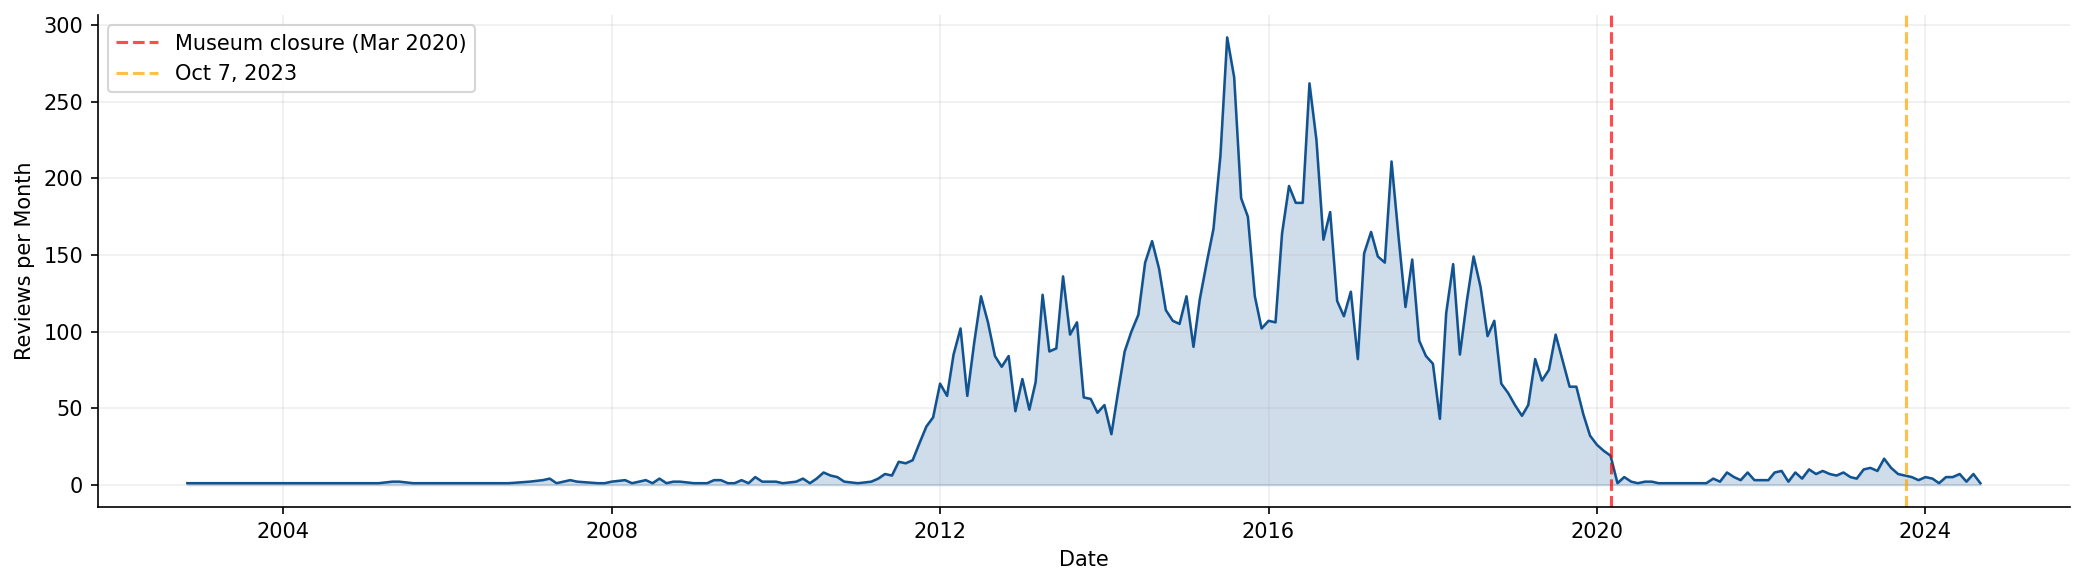

In [10]:
# Monthly counts — full series
monthly = df.groupby("month").size().rename("reviews")
monthly_idx = monthly.index.to_timestamp()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(monthly_idx, monthly.values, color="#115391", linewidth=1.2)
ax.fill_between(monthly_idx, monthly.values, alpha=0.2, color="#115391")
ax.axvline(pd.Timestamp("2020-03-01"), color="red",
           linestyle="--", alpha=0.7, label="Museum closure (Mar 2020)")
ax.axvline(pd.Timestamp("2023-10-07"), color="orange",
           linestyle="--", alpha=0.7, label="Oct 7, 2023")
ax.set_xlabel("Date")
ax.set_ylabel("Reviews per Month")
ax.legend()
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig("../Outputs/Figures/temporal_monthly_trend.png", dpi=300)
plt.show()

In [11]:
# COVID impact summary
periods = {
    "Pre-COVID peak (2015-2019)": (2015, 2019),
    "COVID (2020-2021)": (2020, 2021),
    "Post-COVID (2022-2024)": (2022, 2024)
}
print("Review counts by period:")
for label, (y1, y2) in periods.items():
    n = df[df["year"].between(y1, y2)].shape[0]
    pct = n / len(df) * 100
    print(f"  {label}: {n:,} ({pct:.1f}% of corpus)")

# Oct 7 window
print("\nMonthly counts around Oct 7, 2023:")
window = monthly["2023-07":"2024-06"]
print(window.to_string())

Review counts by period:
  Pre-COVID peak (2015-2019): 7,583 (66.7% of corpus)
  COVID (2020-2021): 119 (1.0% of corpus)
  Post-COVID (2022-2024): 200 (1.8% of corpus)

Monthly counts around Oct 7, 2023:
month
2023-07    17
2023-08    11
2023-09     7
2023-11     5
2023-12     3
2024-01     5
2024-02     4
2024-03     1
2024-04     5
2024-05     5
2024-06     7
Freq: M


## 4. Platform Analysis

In [12]:
platform_counts = df["platform"].value_counts()
print("Platform distribution:")
print(platform_counts)
print()
print(platform_counts / len(df) * 100)

Platform distribution:
platform
OTHER     8506
MOBILE    2790
TABLET      71
Name: count, dtype: int64

platform
OTHER     74.830650
MOBILE    24.544735
TABLET     0.624615
Name: count, dtype: float64


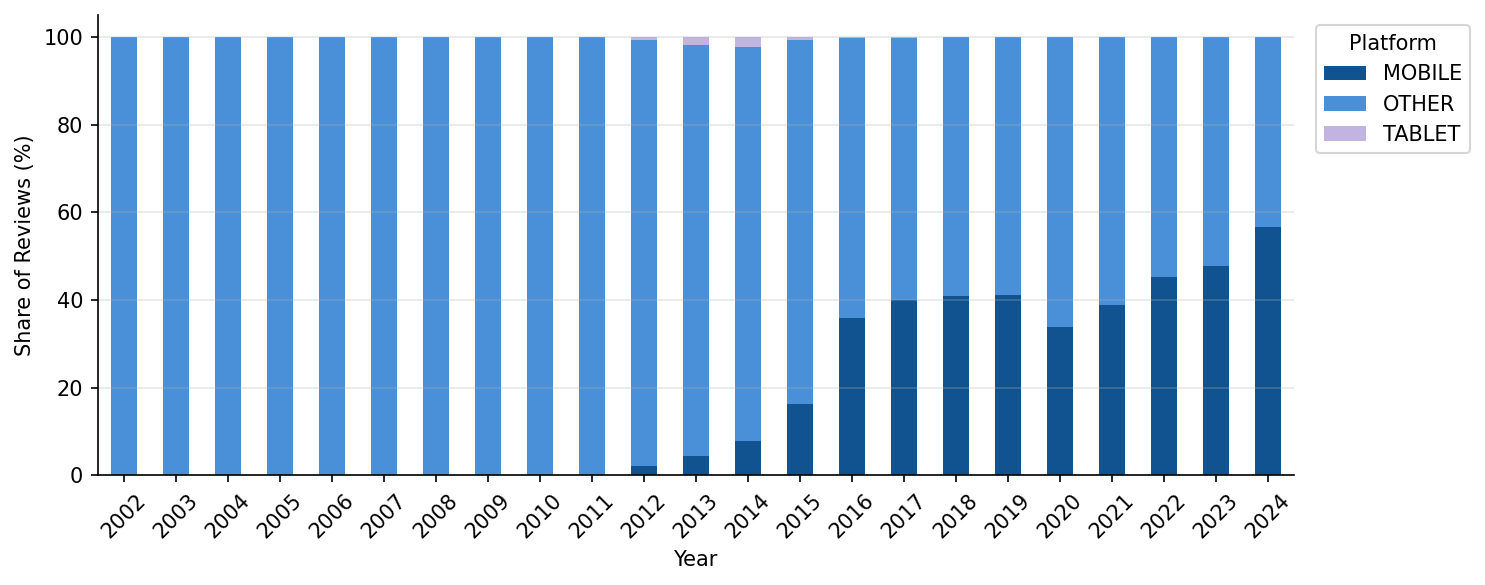

In [13]:
# Platform share over time
platform_year = (df.groupby(["year", "platform"])
                   .size()
                   .unstack(fill_value=0))
platform_pct = platform_year.div(platform_year.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(10, 4))
platform_pct.plot(kind="bar", stacked=True, ax=ax,
                  color=["#115391", "#4a90d9", "#c1b4e1"])
ax.set_xlabel("Year")
ax.set_ylabel("Share of Reviews (%)")
ax.set_xticklabels(platform_pct.index, rotation=45)
ax.legend(title="Platform", bbox_to_anchor=(1.01, 1))
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("../Outputs/Figures/platform_by_year.png", dpi=300)
plt.show()

In [14]:
# Does platform affect review length or rating?
df["review_length"] = df["review_text"].astype(str).str.len()
print("Mean review length by platform:")
print(df.groupby("platform")["review_length"].mean().round(0))
print("\nMean rating by platform:")
print(df.groupby("platform")["rating"].mean().round(3))

Mean review length by platform:
platform
MOBILE    385.0
OTHER     424.0
TABLET    513.0
Name: review_length, dtype: float64

Mean rating by platform:
platform
MOBILE    4.686
OTHER     4.711
TABLET    4.606
Name: rating, dtype: float64


## 5. Reviewer Experience

In [15]:
print("Reviewer total contributions (experience):")
print(df["reviewer_total_contributions"].describe().round(1))

print("\nReviewer helpful votes (credibility):")
print(df["reviewer_helpful_votes"].describe().round(1))

# Experience tiers
df["experience_tier"] = pd.cut(
    df["reviewer_total_contributions"],
    bins=[0, 10, 50, 200, float("inf")],
    labels=["New (1-10)", "Regular (11-50)",
            "Experienced (51-200)", "Power user (200+)"]
)
print("\nReviewer experience tiers:")
print(df["experience_tier"].value_counts())
print("\nMean rating by experience tier:")
print(df.groupby("experience_tier")["rating"].mean().round(3))

Reviewer total contributions (experience):
count     11365.0
mean        262.0
std        1610.5
min           0.0
25%          27.0
50%          71.0
75%         176.0
max      103414.0
Name: reviewer_total_contributions, dtype: float64

Reviewer helpful votes (credibility):
count    11365.0
mean        83.2
std        826.6
min          0.0
25%          9.0
50%         31.0
75%         72.0
max      82820.0
Name: reviewer_helpful_votes, dtype: float64

Reviewer experience tiers:
experience_tier
Experienced (51-200)    4298
Regular (11-50)         3379
Power user (200+)       2510
New (1-10)              1176
Name: count, dtype: int64

Mean rating by experience tier:
experience_tier
New (1-10)              4.695
Regular (11-50)         4.719
Experienced (51-200)    4.715
Power user (200+)       4.673
Name: rating, dtype: float64


/tmp/ipykernel_3269/4293740634.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby("experience_tier")["rating"].mean().round(3))


## 6. Owner Responses

In [16]:
responded = df["has_owner_response"].sum()
print(f"Reviews with USHMM owner response: {responded} ({responded/len(df)*100:.1f}%)")

print("\nRating distribution of reviews that received a response:")
print(df[df["has_owner_response"]]["rating"].value_counts().sort_index())

print("\nFor comparison — overall rating distribution:")
print(df["rating"].value_counts().sort_index())

# Are responses more common for low-rated reviews?
response_rate_by_rating = df.groupby("rating")["has_owner_response"].mean() * 100
print("\nResponse rate by star rating (%):")
print(response_rate_by_rating.round(2))

Reviews with USHMM owner response: 118 (1.0%)

Rating distribution of reviews that received a response:
rating
1     3
2     8
3    10
4    19
5    78
Name: count, dtype: int64

For comparison — overall rating distribution:
rating
1      80
2     131
3     491
4    1665
5    9000
Name: count, dtype: int64

Response rate by star rating (%):
rating
1    3.75
2    6.11
3    2.04
4    1.14
5    0.87
Name: has_owner_response, dtype: float64


In [17]:
# Sample owner responses
print("Sample USHMM owner responses:")
for _, row in df[df["has_owner_response"]].head(3).iterrows():
    print(f"\n  Review rating: ★{int(row['rating'])}")
    print(f"  Review: '{str(row['review_text'])[:150]}...'")
    print(f"  Response: '{str(row['owner_response_text'])[:200]}...'")

Sample USHMM owner responses:

  Review rating: ★5
  Review: 'This museum is incredible and incredibly important now that most of the survivors of the Holocaust are gone.  Such difficult subject matter handled so...'
  Response: 'Thank you for visiting our museum....'

  Review rating: ★5
  Review: 'I visited the Holocaust Museum in August 2024.  I visited here several times many years ago so some things are either new or I never noticed them.  Th...'
  Response: 'Thank you for sharing your experience with us....'

  Review rating: ★4
  Review: 'I learned so much. The place has a very sad vibe to it. There is a lot of reading. Lots of pictures to look at and videos to watch....'
  Response: 'Thank you for sharing your experience with us....'


## 7. Review Title Analysis

In [18]:
print(f"Reviews with titles: {df['review_title'].notna().sum()} (100%)")
print("\nSample titles by rating:")
for rating in [5, 3, 1]:
    titles = df[df["rating"] == rating]["review_title"].dropna().head(3).tolist()
    print(f"\n  ★{rating}:")
    for t in titles:
        print(f"    '{t}'")

Reviews with titles: 11367 (100%)

Sample titles by rating:

  ★5:
    'Very heartfelt, passionate, informitive'
    'When an old man explained the Warsaw milk cans to the visitors, I was moved to tears'
    'This place is incredible'

  ★3:
    'Great message but not the best setup or professional employees.'
    'Informative, but confined'
    'Sad yet educative I highly recommend'

  ★1:
    'Too crowded to appreciate it'
    'Not worth the time and effort'
    'Great exhibit, horrible design'


## 8. English-Only Filter + Final Stats

In [19]:
df_en = df[df["lang"] == "en"].reset_index(drop=True)
print(f"English reviews: {len(df_en)} ({len(df_en)/len(df)*100:.1f}%)")
print(f"Non-English removed: {len(df) - len(df_en)}")

print("\nRating distribution (English only):")
print(df_en["rating"].value_counts().sort_index())
print(f"Mean rating: {df_en['rating'].mean():.3f}")

print("\nGroup type (English only):")
print(df_en["group_type"].value_counts())

print("\nPlatform (English only):")
print(df_en["platform"].value_counts())

English reviews: 10114 (89.0%)
Non-English removed: 1253

Rating distribution (English only):
rating
1      75
2     117
3     419
4    1397
5    8106
Name: count, dtype: int64
Mean rating: 4.715

Group type (English only):
group_type
FAMILY      3207
COUPLES     2663
FRIENDS     1332
NONE        1303
SOLO         820
BUSINESS     408
Name: count, dtype: int64

Platform (English only):
platform
OTHER     7590
MOBILE    2467
TABLET      57
Name: count, dtype: int64


## 9. Export Clean CSV

In [20]:
# Export full dataset (all languages) with new columns
export_cols = [
    "review_id", "rating", "review_title", "review_text",
    "group_type", "reviewer_location", "likes",
    "published_date", "travel_date", "year", "month",
    "platform", "lang",
    "reviewer_total_contributions", "reviewer_helpful_votes",
    "has_owner_response", "owner_response_text",
    "review_length", "experience_tier"
]

# Full dataset
df[export_cols].to_csv(
    "../Data/Processed/ushmm_tripadvisor_full_clean.csv", index=False
)
print(f"Saved full dataset: {len(df)} rows → ushmm_tripadvisor_full_clean.csv")

# English-only version (replaces the original ushmm_tripadvisor_eng.csv)
df_en[export_cols].to_csv(
    "../Data/Processed/ushmm_tripadvisor_eng_full.csv", index=False
)
print(f"Saved English dataset: {len(df_en)} rows → ushmm_tripadvisor_eng_full.csv")
print(f"\nNew columns vs original:")
print("  Added: published_date, travel_date, year, month, platform,")
print("         reviewer_total_contributions, reviewer_helpful_votes,")
print("         has_owner_response, owner_response_text,")
print("         review_length, experience_tier, review_title, review_id")

Saved full dataset: 11367 rows → ushmm_tripadvisor_full_clean.csv
Saved English dataset: 10114 rows → ushmm_tripadvisor_eng_full.csv

New columns vs original:
  Added: published_date, travel_date, year, month, platform,
         reviewer_total_contributions, reviewer_helpful_votes,
         has_owner_response, owner_response_text,
         review_length, experience_tier, review_title, review_id
